In [2]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [8]:
import pandas as pd

# Load dataset
df = pd.read_csv("instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv")

# Display first 5 rows
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [9]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 2000
Number of Columns: 12


In [10]:
print(df.columns.tolist())

['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate']


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   str    
 1   instructor_id               2000 non-null   str    
 2   course_id                   2000 non-null   str    
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), str(3)
memory usage: 216.9 KB


In [12]:
print(df.isnull().sum())

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64


In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [14]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


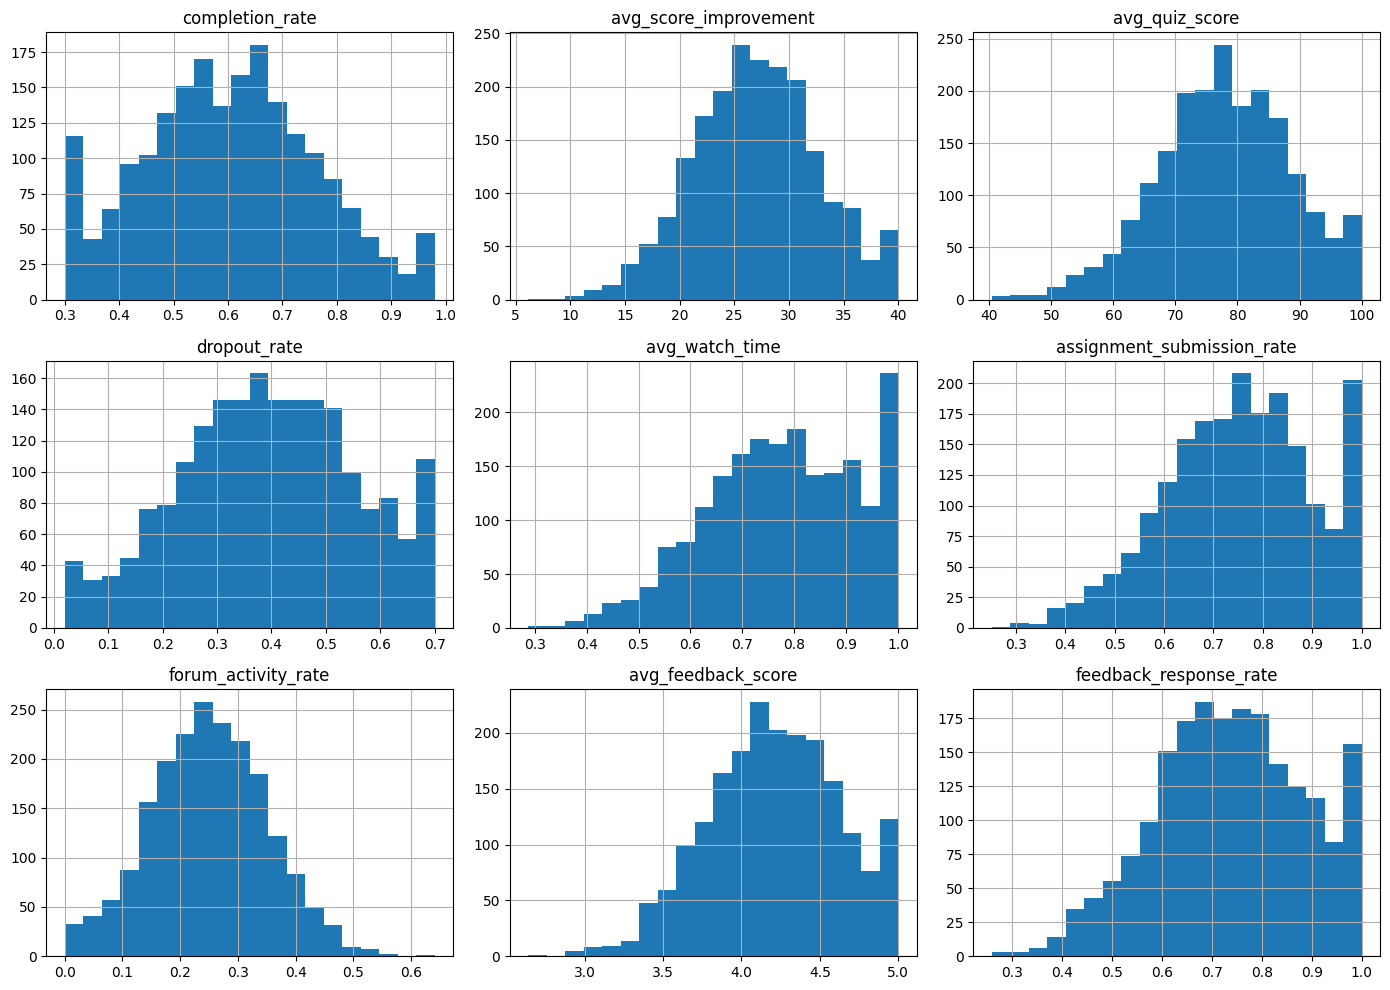

In [15]:
df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

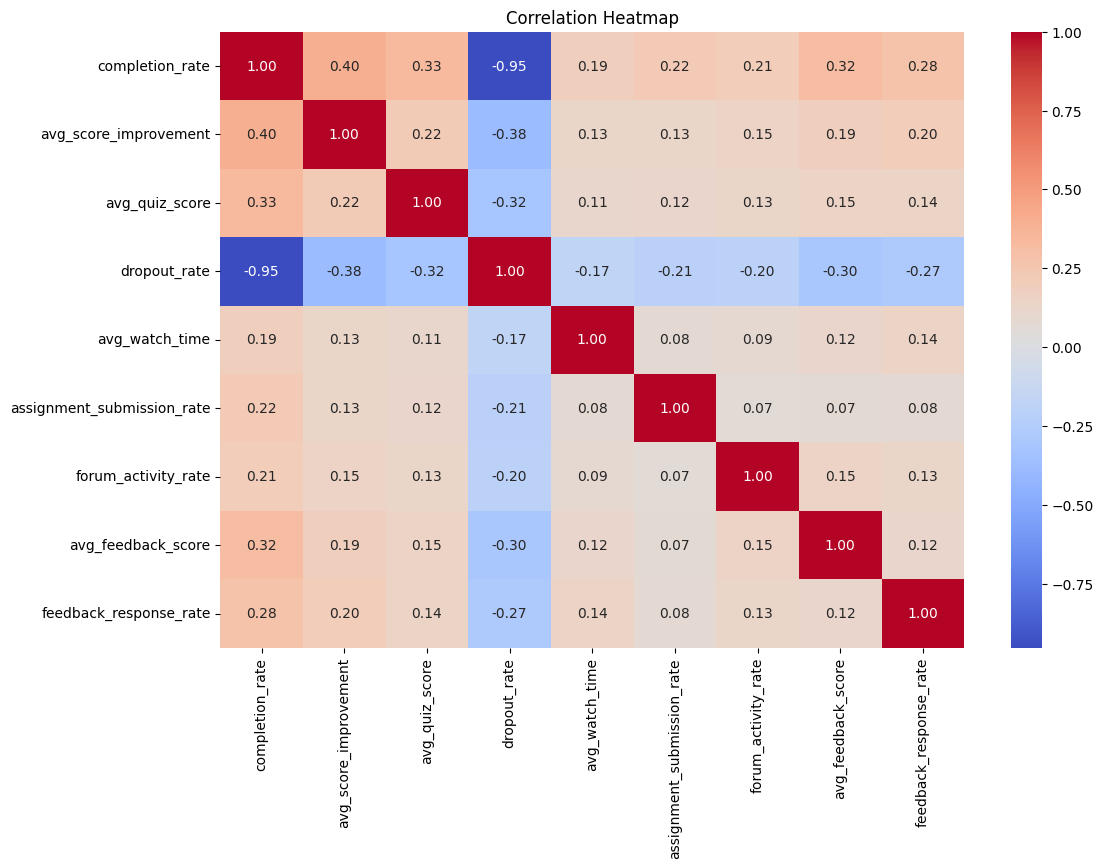

In [16]:
plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

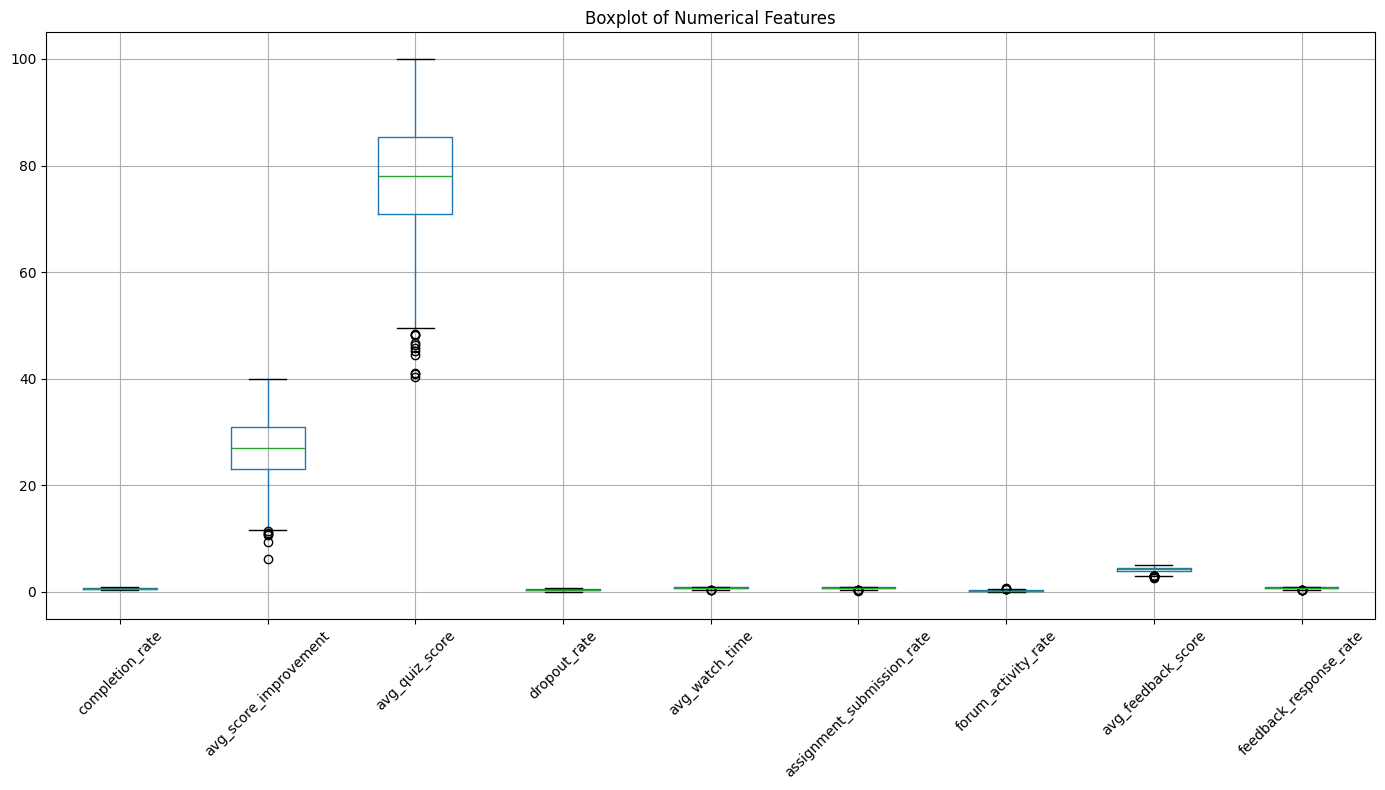

In [17]:
plt.figure(figsize=(14, 8))

numeric_df.boxplot()

plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.tight_layout()
plt.show()

In [18]:
# Create Instructor Effectiveness Score

df["effectiveness_score"] = (
    0.25 * df["completion_rate"]
    + 0.15 * (1 - df["dropout_rate"])
    + 0.20 * df["avg_score_improvement"]
    + 0.10 * df["avg_quiz_score"]
    + 0.10 * df["avg_watch_time"]
    + 0.05 * df["assignment_submission_rate"]
    + 0.05 * df["forum_activity_rate"]
    + 0.10 * (df["avg_feedback_score"] / 5)
)

df[["instructor_id", "effectiveness_score"]].head()

,instructor_id,effectiveness_score
0,I_044,10.525478
1,I_119,12.769445
2,I_050,11.512726
3,I_024,15.252698
4,I_001,16.595493


In [19]:
print(df["effectiveness_score"].min())
print(df["effectiveness_score"].max())

7.375945617975001
18.526882851125


In [20]:
df["effectiveness_tier"] = pd.qcut(
    df["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df[["instructor_id", "effectiveness_score", "effectiveness_tier"]].head(10)

,instructor_id,effectiveness_score,effectiveness_tier
0,I_044,10.525478,Low
1,I_119,12.769445,Low
2,I_050,11.512726,Low
3,I_024,15.252698,High
4,I_001,16.595493,High
5,I_026,13.735072,Medium
6,I_082,13.071210,Medium
7,I_009,13.169787,Medium
8,I_114,14.778806,High
9,I_038,11.128084,Low


In [21]:
print(df["effectiveness_tier"].value_counts())

effectiveness_tier
Low       667
High      667
Medium    666
Name: count, dtype: int64


In [22]:
(1 - df["dropout_rate"])

0       0.352577
1       0.574902
2       0.300000
3       0.665343
4       0.478901
          ...   
1995    0.566563
1996    0.896439
1997    0.487734
1998    0.682769
1999    0.300000
Name: dropout_rate, Length: 2000, dtype: float64

In [23]:
df["avg_feedback_score"] / 5

0       0.753242
1       1.000000
2       0.703477
3       0.841516
4       0.885246
          ...   
1995    0.867896
1996    0.982587
1997    0.842223
1998    0.836428
1999    0.884062
Name: avg_feedback_score, Length: 2000, dtype: float64

### Definition of Instructor Effectiveness

Instructor effectiveness is defined as a composite score based on learner outcomes,
engagement, and learner feedback.

Learner outcome metrics are given higher weights because they directly represent
learning and course completion. Engagement metrics are also included because
consistent learner participation can indicate effective instruction. Feedback is
included as a supporting measure of learner satisfaction.

The dropout rate is reverse-scaled because a lower dropout rate indicates better
instructor effectiveness.

The resulting effectiveness score is divided into three tiers: Low, Medium, and High.
Quantile-based thresholds are used to create relatively balanced classes.

In [26]:
instructor_df = df.groupby("instructor_id").agg({
    "completion_rate": "mean",
    "dropout_rate": "mean",
    "avg_score_improvement": "mean",
    "avg_quiz_score": "mean",
    "avg_watch_time": "mean",
    "assignment_submission_rate": "mean",
    "forum_activity_rate": "mean",
    "avg_feedback_score": "mean",
    "feedback_response_rate": "mean",
    "effectiveness_score": "mean"
}).reset_index()

instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,13.643073
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,14.726407
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,14.686179
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,12.742999
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,15.672899


In [27]:
batch_counts = df.groupby("instructor_id")["batch_id"].nunique().reset_index()

batch_counts.columns = ["instructor_id", "batch_count"]

instructor_df = instructor_df.merge(
    batch_counts,
    on="instructor_id",
    how="left"
)

instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,batch_count
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,13.643073,25
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,14.726407,20
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,14.686179,18
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,12.742999,17
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,15.672899,19


In [28]:
instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,batch_count,effectiveness_tier
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,13.643073,25,Medium
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,14.726407,20,High
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,14.686179,18,High
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,12.742999,17,Low
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,15.672899,19,High


In [29]:
print("Total instructors:", instructor_df["instructor_id"].nunique())
print("Total rows:", len(instructor_df))


Total instructors: 120
Total rows: 120


In [30]:
print(instructor_df["effectiveness_tier"].value_counts())

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64


In [32]:
instructor_df["batch_count"].describe()

count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
Name: batch_count, dtype: float64

In [33]:
instructor_df = df.groupby("instructor_id").agg({
    "completion_rate": "mean",
    "dropout_rate": "mean",
    "avg_score_improvement": "mean",
    "avg_quiz_score": "mean",
    "avg_watch_time": "mean",
    "assignment_submission_rate": "mean",
    "forum_activity_rate": "mean",
    "avg_feedback_score": "mean",
    "feedback_response_rate": "mean",
    "effectiveness_score": "mean"
}).reset_index()

instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,13.643073
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,14.726407
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,14.686179
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,12.742999
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,15.672899


In [34]:
batch_counts = df.groupby("instructor_id")["batch_id"].nunique().reset_index()

batch_counts.columns = ["instructor_id", "batch_count"]

instructor_df = instructor_df.merge(
    batch_counts,
    on="instructor_id",
    how="left"
)

instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,batch_count
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,13.643073,25
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,14.726407,20
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,14.686179,18
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,12.742999,17
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,15.672899,19


In [36]:
print(instructor_df.columns.tolist())

['instructor_id', 'completion_rate', 'dropout_rate', 'avg_score_improvement', 'avg_quiz_score', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate', 'effectiveness_score', 'batch_count']


In [37]:
# Create effectiveness tier at instructor level

instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print(instructor_df.head())
print("\nTier Distribution:")
print(instructor_df["effectiveness_tier"].value_counts())

  instructor_id  completion_rate  dropout_rate  avg_score_improvement  \
0         I_001         0.543887      0.470593              26.641462   
1         I_002         0.730874      0.247194              30.166242   
2         I_003         0.768447      0.234828              29.977813   
3         I_004         0.458328      0.547261              22.912021   
4         I_005         0.859747      0.145733              32.588652   

   avg_quiz_score  avg_watch_time  assignment_submission_rate  \
0       78.900194        0.766513                    0.726893   
1       81.737198        0.837393                    0.774394   
2       81.590928        0.818441                    0.779606   
3       77.680317        0.793130                    0.758317   
4       85.828159        0.847026                    0.876942   

   forum_activity_rate  avg_feedback_score  feedback_response_rate  \
0             0.240551            4.217743                0.694858   
1             0.289610        

In [38]:
# Select features

X = instructor_df.drop(
    ["instructor_id", "effectiveness_score", "effectiveness_tier"],
    axis=1
)

# Target
y = instructor_df["effectiveness_tier"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.value_counts())

Features:
['completion_rate', 'dropout_rate', 'avg_score_improvement', 'avg_quiz_score', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate', 'batch_count']

Target:
effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model training completed.")

Model training completed.


In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9583333333333334


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         8
         Low       0.89      1.00      0.94         8
      Medium       1.00      0.88      0.93         8

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



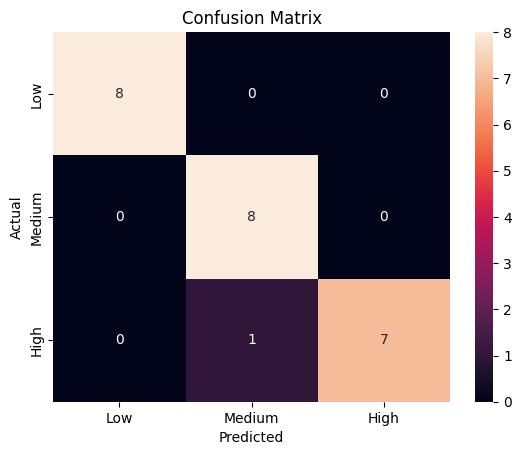

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                      Feature  Importance
2       avg_score_improvement    0.268929
1                dropout_rate    0.193580
0             completion_rate    0.186659
3              avg_quiz_score    0.119593
8      feedback_response_rate    0.058795
6         forum_activity_rate    0.048965
7          avg_feedback_score    0.042669
4              avg_watch_time    0.034079
5  assignment_submission_rate    0.032434
9                 batch_count    0.014296


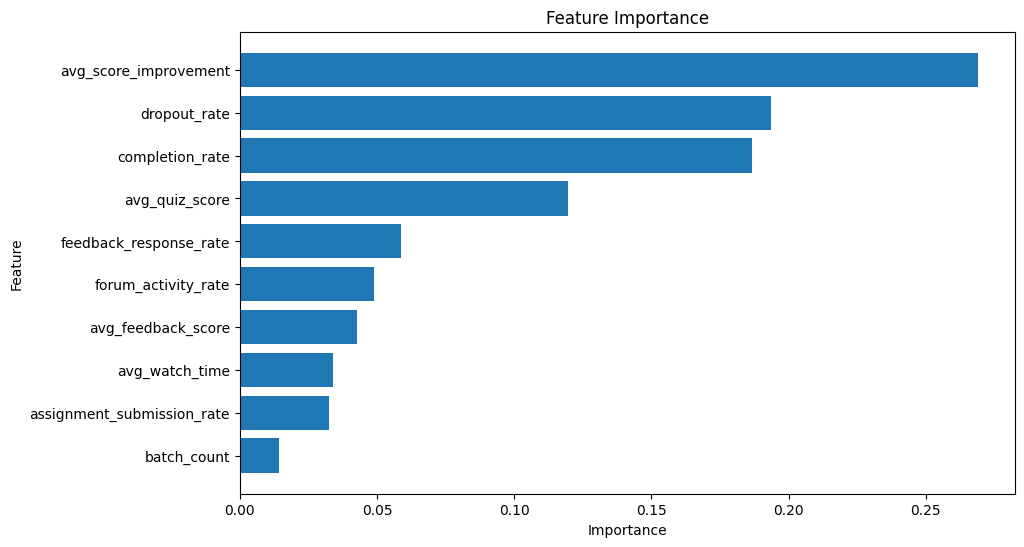

In [45]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.gca().invert_yaxis()
plt.show()

### 1. Which features most influenced instructor effectiveness?

The most important feature was avg_score_improvement, with an importance of approximately 0.269.
This means learner improvement had the strongest influence on the model.

Dropout_rate and completion_rate were the next most important features, with importance
values of approximately 0.194 and 0.187.

These features are important because they directly reflect learner outcomes. A good
instructor should help learners improve their knowledge, complete the course, and
reduce dropout.

### 2. Which variables could be misleading or confounded?

Some variables may be influenced by factors other than the instructor.

For example, dropout rate and completion rate can be affected by course difficulty,
learner motivation, batch size, and personal circumstances. Quiz scores can also
depend on the difficulty of the assessments.

Another important limitation is that the effectiveness score and effectiveness tiers
were created using several of the same variables used as model features. Therefore,
the high model accuracy may partly reflect this relationship rather than true
real-world predictive ability.

### 3. How could this model fail in real-world usage?

The model may not perform as well on completely new instructors or batches.

Learner behavior, course difficulty, assessment difficulty, and teaching conditions
may change over time. The model may also give unreliable results for instructors
with very few batches.

Therefore, the model should be regularly monitored and evaluated using new data.

### 4. What additional data would you want?

I would like to include additional information such as:

- Instructor teaching experience
- Batch size
- Course difficulty
- Learner attendance
- Learner prior knowledge
- Assignment quality
- Instructor interaction time
- Number of live sessions
- Historical instructor performance

These variables could help separate instructor performance from learner and course-related factors.

### 5. Should this model be used for instructor performance evaluation?

The model should not be used as the only method for evaluating instructors.

It can be used as a decision-support tool along with learner feedback, course
difficulty, batch characteristics, instructor experience, and human review.

This is important because some factors affecting learner outcomes are outside
the instructor's control. Using the model alone could lead to unfair evaluations.